# **Tema završnog rada: Kvantifikacija nesigurnosti u modelima umjetne inteligencije - okvir za prediktivno održavanje i analizu rizika**

> *Napomena: Notebook se koristi kao radno i eksperimentalno okruženje za implementaciju i testiranje modela u sklopu BSc završnog rada.*



## 1. Setup

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

## 2. Load dataset (CMAPSS)

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import pandas as pd

train = pd.read_csv('/content/drive/MyDrive/CMAPSS/train_FD001.txt', sep=r'\s+', header=None)

test = pd.read_csv('/content/drive/MyDrive/CMAPSS/test_FD001.txt', sep=r'\s+', header=None)

rul = pd.read_csv('/content/drive/MyDrive/CMAPSS/RUL_FD001.txt', sep=r'\s+', header=None)

In [46]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Preprocessing

Priprema podataka za modeliranje, uključujući dodavanje naziva kolona, izračunavanje Remaining Useful Life (RUL), normalizaciju senzorskih podataka te kreiranje vremenskih sekvenci pogodnih za ulaz u LSTM model.

In [47]:
columns = ['engine_id', 'cycle']

operational_settings = [f'op_setting_{i}' for i in range(1, 4)]
sensor_columns = [f'sensor_{i}' for i in range(1, 22)]

columns += operational_settings + sensor_columns

train.columns = columns
test.columns = columns

In [48]:
train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [49]:
train.isna().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [50]:
test.isna().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


Nema nedostajućih vrijednosti (NaN) ni u jednoj koloni.

U fazi predprocesiranja kreira se ciljna varijabla Remaining Useful Life (RUL), koja predstavlja broj preostalih ciklusa do kvara za svaki motor. Ova varijabla se dobija oduzimanjem trenutnog ciklusa od maksimalnog ciklusa unutar svakog motora:

In [51]:
train['RUL'] = train.groupby('engine_id')['cycle'].transform('max') - train['cycle']

In [52]:
RUL_MAX = 125
train['RUL'] = train['RUL'].clip(upper=RUL_MAX)

In [53]:
train[['engine_id', 'cycle', 'RUL']].head(5)

,engine_id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


In [54]:
feature_columns = operational_settings + sensor_columns

NORMALIZACIJA:

In [55]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train[feature_columns] = scaler.fit_transform(train[feature_columns])
test[feature_columns] = scaler.transform(test[feature_columns])

In [56]:
seq_length = 30

In [57]:
import numpy as np

def create_sequences(data, seq_length, feature_columns):
    xs = []
    ys = []

    for engine_id in data['engine_id'].unique():

        engine_data = data[data['engine_id'] == engine_id]

        for i in range(len(engine_data) - seq_length):

            x = engine_data.iloc[i:i+seq_length][feature_columns].values
            y = engine_data.iloc[i+seq_length]['RUL']

            xs.append(x)
            ys.append(y)

    return np.array(xs), np.array(ys)

In [58]:
X_train, y_train = create_sequences(train, seq_length, feature_columns)

In [59]:
print(X_train.shape)
print(y_train.shape)

(17631, 30, 24)
(17631,)


## 4. Baseline model

> Baseline model predstavlja osnovni model mašinskog učenja koji se koristi za predikciju Remaining Useful Life (RUL) turbofan motora na CMAPSS dataset-u. Ovaj model nema implementirane metode kvantifikacije nesigurnosti, već daje jednu determinističku (tačnu) numeričku predikciju preostalog vijeka trajanja.
> Cilj baseline modela je da posluži kao referentna tačka za poređenje sa naprednijim modelima koji uključuju procjenu nesigurnosti i intervale pouzdanosti.

In [70]:
model = Sequential([
    Input(shape=(seq_length, len(feature_columns))),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

In [71]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [72]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 4211.8975 - mae: 54.7293 - val_loss: 1995.0328 - val_mae: 40.4412
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1827.9385 - mae: 37.6864 - val_loss: 1798.9242 - val_mae: 38.1969
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1809.5597 - mae: 37.3650 - val_loss: 1812.1495 - val_mae: 38.4207
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1819.9657 - mae: 37.5490 - val_loss: 1817.4683 - val_mae: 38.5020
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1806.5228 - mae: 37.3746 - val_loss: 1819.8002 - val_mae: 38.5371
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1809.8705 - mae: 37.4051 - val_loss: 1769.0380 - val_mae: 37.9780
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 764.1716 - mae: 21.9476 - val_loss: 247.5364 - val_mae: 13.1789
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 353.2338 - mae: 14.3821 - val_loss: 231.5278 - val_mae: 

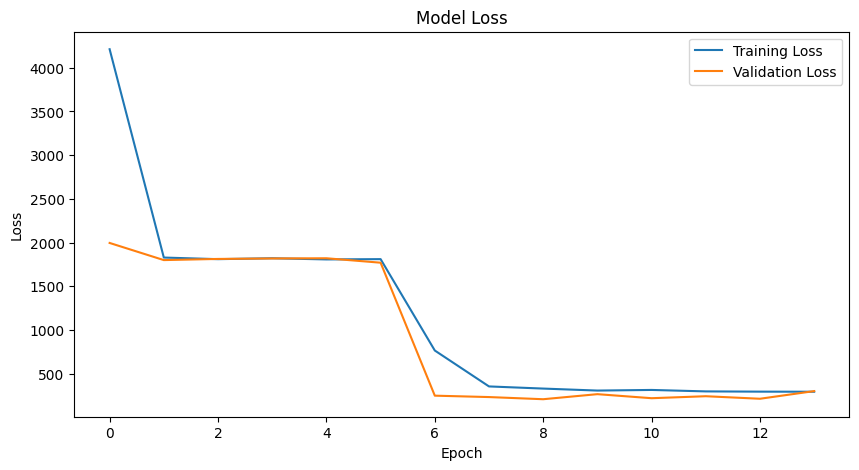

In [73]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

Model pokazuje zdravu konvergenciju i odličnu generalizaciju. Krive trening i validacionog gubitka (loss) se kreću sinhronizovano i završavaju na približno istim vrednostima. Ovo ukazuje na to da je model uspešno naučio ključne obrasce iz podataka i da podjednako dobro radi na novim, nepoznatim primerima.

In [74]:
X_test = []

for engine_id in test['engine_id'].unique():

    engine_data = test[test['engine_id'] == engine_id]

    if len(engine_data) >= seq_length:

        seq = engine_data.iloc[-seq_length:][feature_columns].values
        X_test.append(seq)

X_test = np.array(X_test)

print(X_test.shape)

(100, 30, 24)


In [75]:
predictions = model.predict(X_test)

print(predictions[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[[115.180664]
 [117.827194]
 [ 57.776875]
 [ 94.262665]
 [105.19524 ]
 [112.74912 ]
 [102.71645 ]
 [100.98066 ]
 [118.32273 ]
 [ 90.724815]]


In [77]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_test = rul[0].values

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 16.046705740952525
MAE: 12.074807167053223


Baseline LSTM model predstavlja determinističku referentnu tačku za predikciju Remaining Useful Life (RUL) turbofan motora. Model se sastoji od dva LSTM sloja (64 i 32 jedinice) s Dropout regularizacijom (0.3) između njih, te dva Dense sloja. Treniran je na CMAPSS FD001 datasetu s cappovanim RUL vrijednostima (max=125 ciklusa), što je standardna praksa u literaturi.
Model postiže RMSE = 16.05 i MAE = 12.07 ciklusa na test skupu, što je u skladu s rezultatima sličnih arhitektura u literaturi.
Ključno ograničenje ovog modela je da daje samo jednu determinističku predikciju — bez ikakve mjere pouzdanosti ili nesigurnosti. Ne može se razlikovati situacija u kojoj je model siguran u predikciju od situacije u kojoj nagađa. Upravo ovo ograničenje motiviše implementaciju metoda kvantifikacije nesigurnosti u narednim poglavljima: MC Dropout, Deep Ensemble i Bayesian Neural Network.

## 5. Evaluation

## 6. Uncertainty